# Mouse time series analysis

In [190]:
import sys
sys.path.insert(0, '..')
import random

import pandas as pd
import numpy as np

import seaborn as sns

from scipy.optimize import leastsq
from scipy.stats import mannwhitneyu
import scipy.stats as stats
from scipy.optimize import curve_fit

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
from matplotlib.ticker import ScalarFormatter
import matplotlib.image as mpimg
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from matplotlib.patches import Rectangle

from matplotlib.lines import Line2D
from matplotlib.ticker import FormatStrFormatter

import warnings
import copy

from statsmodels.stats.multitest import multipletests



from utils.utils import *

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
np.random.seed(1)
random.seed(42)

pd.options.mode.chained_assignment = None

figures='../paper_and_outputs/figures/'
data_location = '../measurement_data/'
mouse_data_name = 'mouse_time_series_exp3_conv.xlsx'
mouse_data_full_path = data_location+mouse_data_name
statistical_data_path = '../paper_and_outputs/tables/statistical_data_tables.xlsx'
extended_data_path = '../paper_and_outputs/tables/extended_data_tables.xlsx'
mouse_svg_path= '../aux_files/lab_mouse.svg'

display_names = {'il6':'IL-6','il10':'IL-10','il18':'IL-18','il17':'IL-17','il22':'IL-22','il1b':'IL-1\u03b2','tnfa':'TNF-\u03b1'} 


conc_epsilon= 0
scale= 3.29 # this arises because LOD is 
#LOD=E_blank + 1.645*SD_blank + 1.645*SD_conc_lowest_standard      or equivalently
#LOD=E_blank + 3.29*(SD_blank+SD_lowest_standard)/2


In [191]:
def kendalls_w_from_rank_matrix(rank_mat: np.ndarray) -> float:
    # rank_mat shape: (m_timepoints, n_mice)
    m, n = rank_mat.shape
    R = rank_mat.sum(axis=0)
    Rbar = m * (n + 1) / 2.0
    S = ((R - Rbar) ** 2).sum()
    W = 12 * S / (m**2 * (n**3 - n))
    return float(W)

def rank_matrix(df, time_col="time", mouse_col="mouse", value_col="value", ascending=True):
    # ascending=True makes smallest rank 1. If you want "highest cytokine = rank 1", set ascending=False.
    wide = df.pivot(index=time_col, columns=mouse_col, values=value_col).dropna()
    # ranks within each timepoint, handling ties by average rank
    ranks = wide.rank(axis=1, method="average", ascending=ascending)
    return ranks.to_numpy(), wide.index.to_numpy(), wide.columns.to_numpy()

def perm_test_w_label_shuffle(df, B=20000, seed=0, **kwargs):
    R, times, mice = rank_matrix(df, **kwargs)
    W_obs = kendalls_w_from_rank_matrix(R)
    rng = np.random.default_rng(seed)
    m, n = R.shape
    W_null = np.empty(B)
    for b in range(B):
        # permute mouse labels independently at each timepoint
        Rp = np.vstack([R[k, rng.permutation(n)] for k in range(m)])
        W_null[b] = kendalls_w_from_rank_matrix(Rp)
    p = (1 + (W_null >= W_obs).sum()) / (B + 1)
    return W_obs, p


def perm_test_w_circular_shift(df, B=20000, seed=0, **kwargs):
    # preserves each mouse's temporal pattern; breaks consistent ordering alignment
    wide = df.pivot(index="time", columns="mouse", values="value").dropna()
    Y = wide.to_numpy()
    m, n = Y.shape
    W_obs, _, _ = (lambda d: (kendalls_w_from_rank_matrix(d), None, None))(
        wide.rank(axis=1, method="average", ascending=kwargs.get("ascending", True)).to_numpy()
    )
    rng = np.random.default_rng(seed)
    W_null = np.empty(B)
    for b in range(B):
        shifts = rng.integers(0, m, size=n)
        Yp = np.column_stack([np.roll(Y[:, j], shifts[j]) for j in range(n)])
        Rp = pd.DataFrame(Yp).rank(axis=1, method="average", ascending=kwargs.get("ascending", True)).to_numpy()
        W_null[b] = kendalls_w_from_rank_matrix(Rp)
    p = (1 + (W_null >= W_obs).sum()) / (B + 1)
    return W_obs, p

In [192]:
def clean_cals_vals(cals, vals, conc_epsilon=1e-7):
  melted_cals = {}
  calambnames = ['amb1','amb2']#,'amb3','amb4']
  calmeanpnames = ['meanp1','meanp2']#,'meanp3','meanp4']
  calmeannames = ['mean_all1','mean_all2']#,'mean_all3','mean_all4']
 
  for k, df in cals.items():
    df_avg = df.copy()
  
    df_avg['amb'] = stats.gmean(df[calambnames], axis=1, nan_policy='omit')
    df_avg['meanp'] = stats.gmean(df[calmeanpnames],  axis=1,nan_policy='omit') 
    df_avg['mean_all'] = stats.gmean(df[calmeannames],  axis=1,nan_policy='omit')
  

    df_final = df_avg[['conc', 'amb', 'meanp', 'mean_all']].copy()

    melted_cals[k] = df_final
    melted_cals[k]['amb_deviation']=np.std(df[calambnames], axis=1)
    melted_cals[k]['meanp_deviation']=np.std(df[calmeanpnames], axis=1)
    melted_cals[k]['mean_all_deviation']=np.std(df[calmeannames], axis=1)


  melted_vals = {}
  for k, df in vals.items():
    # Average replicates in log space (geometric mean) for calibration curves
    df_avg = df.copy()
    
    df_avg['amb'] = np.nan
    df_avg['amb'] = stats.gmean(df[['amb1','amb2']], axis=1, nan_policy='omit')

    df_avg['meanp'] = np.nan
    df_avg['meanp'] = stats.gmean(df[['meanp1','meanp2']],  axis=1,nan_policy='omit')

    df_avg['mean_all'] = np.nan
    df_avg['mean_all'] = stats.gmean(df[['mean_all1','mean_all2']],  axis=1,nan_policy='omit')


    df_final = df_avg[['sample','amb', 'meanp', 'mean_all']].copy()
    melted_vals[k] = df_final

  cals = melted_cals
  vals = melted_vals

  for k, df in cals.items():
    cals[k]['conc'] = df['conc'].astype(float)+conc_epsilon
    cals[k]['amb'] = df['amb'].astype(float)
    cals[k]['meanp'] = df['meanp'].astype(float)

  for k, df in vals.items():
    vals[k]['amb'] = df['amb'].astype(float)
    vals[k]['meanp'] = df['meanp'].astype(float)
  
    
  return cals, vals

# EXperimental

In [193]:
sheet1 = pd.read_excel(mouse_data_full_path,header=None)

il17 = sheet1.iloc[:,0:5]
il22 = sheet1.iloc[:,6:11]
il1b = sheet1.iloc[:,12:17]
il6 = sheet1.iloc[:,18:23]
il10 = sheet1.iloc[:,24:29]
il18 = sheet1.iloc[:,30:35]
tnfa = sheet1.iloc[:,36:41]

In [194]:
#look at il6 data extracted from excel sheet
il6

,18,19,20,21,22
0,mIL6 (pg/mL),frac on,NaN,Geo Mean Fl,NaN
1,NaN,replicate 1,replicate 2,replicate 1,replicate 2
2,5000,0.847,0.856,732000,1010000
3,1000,0.903,0.916,650000,661000
4,200,0.914,0.938,73944,120091
5,40,0.936,0.957,41309,37397
6,8,0.635,0.607,11876,11367
7,1.6,0.185,0.2,8626,8688
8,0.32,0.0594,0.0854,8915,8774
9,0.064,0.0254,0.0513,8154,8328


In [195]:
cals = {}
data = {}

cals['il17'] = il17.iloc[2:13,:]
cals['il22'] = il22.iloc[2:13,:]
cals['il6'] = il6.iloc[2:13,:]
cals['il18'] = il18.iloc[2:13,:]
cals['tnfa'] = tnfa.iloc[2:13,:]
cals['il10'] = il10.iloc[2:13,:]
cals['il1b'] = il1b.iloc[2:13,:]


data['il17'] = il17.iloc[14:]
data['il22'] = il22.iloc[14:]
data['il6'] = il6.iloc[14:]
data['il18'] = il18.iloc[14:]
data['tnfa'] = tnfa.iloc[14:]
data['il10'] = il10.iloc[14:]
data['il1b'] = il1b.iloc[14:]

# remove the last nonzero calibrator for il6, completely removing the row 
cals['il6'] = il6.iloc[[2,3,4,5,6,7,8,9,10, 12],:]


In [196]:
# look at cals for il6
cals['il6']

,18,19,20,21,22
2,5000,0.847,0.856,732000,1010000
3,1000,0.903,0.916,650000,661000
4,200,0.914,0.938,73944,120091
5,40,0.936,0.957,41309,37397
6,8,0.635,0.607,11876,11367
7,1.6,0.185,0.2,8626,8688
8,0.32,0.0594,0.0854,8915,8774
9,0.064,0.0254,0.0513,8154,8328
10,0.0128,0.0174,0.0203,9507,7990
12,0,0.0122,0.0121,9578,10019


In [197]:
# look at data for il6
data['il6']

,18,19,20,21,22
14,1-D1/4,0.0692,0.0153,7253,7944
15,1-D5/4,0.0976,0.0285,6976,9077
16,1-D25/4,0.0217,0.02,8138,7882
17,2-D1/4,0.0166,0.0082,7423,6620
18,1-D6/16,0.156,0.164,8383,8217
19,1-D6/48,0.096,0.0476,8097,7453
20,1-D8/48,0.526,0.559,10564,10599
21,1-D19/48,0.682,0.629,12042,11804
22,2-D5/4,0.0401,0.0169,7946,7644
23,2-D25/4,0.048,0.0452,8371,8133


In [198]:
for k,c in cals.items():
  cal_cols=['conc','lambda1','lambda2','meanp1','meanp2']
  c.columns = cal_cols
  c.reset_index(drop=True,inplace=True)
  for col in cal_cols:
    c[col] = c[col].astype(float)
  for col in cal_cols[1:]:
    c[col] = pd.to_numeric(c[col], errors='coerce')
  cals[k] = c

for k,c in cals.items():
 

  c['amb1'] = on_to_amb(c['lambda1'])
  c['amb2'] = on_to_amb(c['lambda2'])
 

  c['mean_all1'] =c['lambda1']*c['meanp1']
  c['mean_all2'] =c['lambda2']*c['meanp2']



  cals[k] = c

In [199]:
for k,v in data.items():
  v.columns = ['sample','lambda1','lambda2','meanp1','meanp2']
  v.reset_index(drop=True,inplace=True)
  v['sample'] = v['sample'].astype(str)
  v.loc[v['lambda1'] == 0, 'lambda1'] = np.nan
  v.loc[v['lambda2'] == 0, 'lambda2'] = np.nan
  v['lambda1'] = v['lambda1'].astype(float)
  v['lambda2'] = v['lambda2'].astype(float)
  v['meanp1'] = v['meanp1'].astype(float)
  v['meanp2'] = v['meanp2'].astype(float)
  data[k] = v

for k,v in data.items():
  v['lambda1'] = pd.to_numeric(v['lambda1'], errors='coerce')
  v['lambda2'] = pd.to_numeric(v['lambda2'], errors='coerce')
  v['meanp1'] = pd.to_numeric(v['meanp1'], errors='coerce')
  v['meanp2'] = pd.to_numeric(v['meanp2'], errors='coerce')
  data[k] = v

for k,v in data.items():
  v['amb1'] = on_to_amb(v['lambda1'])
  v['amb2'] = on_to_amb(v['lambda2'])

  v['mean_all1'] =v['lambda1']*v['meanp1']
  v['mean_all2'] =v['lambda2']*v['meanp2']
  data[k] = v

In [200]:
cals,vals=clean_cals_vals(cals, data, conc_epsilon=conc_epsilon)

In [201]:
order = ['tnfa','il6', 'il10',  'il17','il18', 'il22', 'il1b']
cals = {k: cals[k] for k in order}
vals = {k: vals[k] for k in order}

In [202]:
cals['il6']

,conc,amb,meanp,mean_all,amb_deviation,meanp_deviation,mean_all_deviation
0,5000.0000,1.907389,859837.193892,732141.146392,0.030312,139000.0,122278.00000
1,1000.0000,2.403915,655476.925605,596141.038849,0.071947,5500.0,9263.00000
2,200.0000,2.611895,94233.799159,87253.170680,0.163606,23073.5,22530.27100
3,40.0000,2.940999,39304.359466,37199.287043,0.198841,1956.0,1438.14750
4,8.0000,0.970198,11618.713010,7213.386997,0.036956,254.5,320.74550
5,1.6000,0.213654,8656.944496,1665.196522,0.009288,31.0,70.89500
6,0.3200,0.073936,8844.219016,629.914560,0.014016,70.5,109.87430
7,0.0640,0.036809,8240.540759,297.461835,0.013467,87.0,110.05740
8,0.0128,0.018974,8715.556781,163.801464,0.001478,758.5,1.61240
9,0.0000,0.012224,9796.018681,119.020619,0.000051,220.5,2.18915


/opt/anaconda3/envs/cocktail/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


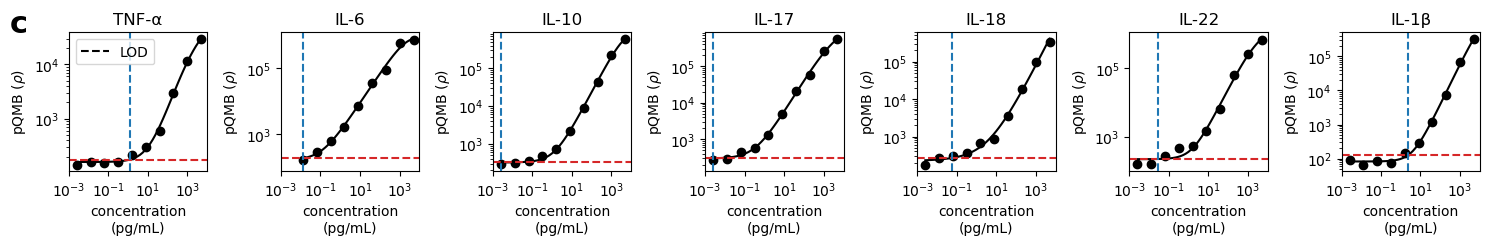

In [203]:
params = {} 
conclimits = {}
measurelimits = {}
llod = {}
llod_conc = {}
llod_conc_ll = {}
ulod = {}
ulod_conc = {}
ulod_conc_ll = {}
xf={}
yf={}
fig, axes = plt.subplots(1, 7, figsize=(15, 3), tight_layout=True)
axes = axes.flatten()
axes2 = axes.copy()

ambval='mean_all' #overloaded parameter name, could be 'amb' or 'mean_all'
ambdev='mean_all_deviation'

for i, (k, df) in enumerate(cals.items()):
  xf[k, ambval], yf[k, ambval], params[k, ambval] = cal_curve_fit(df, x_var='conc', y_var=ambval)

  # Get lowest non-zero concentration
  min_nonzero_conc = min(df[df['conc'] > 0]['conc'])
  max_nonzero_conc = max(df['conc'])
  amb_at_min_conc = df[df['conc'] == min_nonzero_conc][ambval]
  
  conclimits[k] = (min_nonzero_conc, max(df['conc']))
  measurelimits[k,ambval] = (min(amb_at_min_conc), max(df[ambval]))

  axes[i].plot(xf[k,ambval],yf[k,ambval], color='k')

  if k=='il6': # il6 blank is outlier so we use the lowest and second to lowest nonzero concentration to calculate lod
    lasymp=df[ambval][9]
    lstandard_deviation=(df[ambdev][9]+df[ambdev][8])/2
  else:
    lasymp=df[ambval][10]
    lstandard_deviation=(df[ambdev][10]+df[ambdev][9])/2

  llod_std= lasymp+scale*lstandard_deviation

  llod_lowest_conc=linear_5pl(min_nonzero_conc, *params[k, ambval])
  llod[k] = max(llod_std,llod_lowest_conc)

  llod_conc[k]=invlog5pl(llod[k], (params[k, ambval],conclimits[k],measurelimits[k, ambval]))
  
  axes[i].axhline(y=llod[k], color='tab:red', linestyle='--')
  axes[i].axvline(x=llod_conc[k], color='tab:blue', linestyle='--')

  conclimits[k] = (llod_conc[k], conclimits[k][1])
  measurelimits[k, ambval] = (llod[k], measurelimits[k, ambval][1])
  
  axes[i].scatter(df['conc'],df[ambval], color='k')

  axes[i].set_yscale('log')
  axes[i].set_xscale('log')
  # use display names for titles
  axes[i].set_title(display_names.get(k))
  axes2[i].set_xticks([1e-3,1e-1,1e1,1e3])
  axes[i].set_xlabel('concentration\n(pg/mL)')
  axes[i].set_ylabel(r'pQMB ($\rho$)')

  axes[i].set_box_aspect(1)

custom_lines = [Line2D([0], [0], color='k', linestyle='--')]
axes[0].legend(custom_lines, ['LOD'], loc='upper left', fontsize=10)
fig.text(0.01, 0.84, 'c', fontsize=22, fontweight='bold', va='top', ha='left')

plt.tight_layout()
plt.savefig(figures+'mouse_series_standard_curve.pdf', bbox_inches='tight')

In [204]:

day_pattern = r'D(.*?)/'


for k,df in vals.items():
    df['mouse'] = df['sample'].str[0].astype(int)
    # the numbers after the D and before the / is the day
    df['day'] = df['sample'].str.extract(day_pattern).astype(int)
    df['dilution_factor']=df['sample'].str.split('/').str[-1].astype(float)
    df['mouse_type']='conv'
    vals[k] = df

In [205]:
vals['il6']

,sample,amb,meanp,mean_all,mouse,day,dilution_factor,mouse_type
0,1-D1/4,0.033251,7590.641080,246.988777,1,1,4.0,conv
1,1-D5/4,0.054492,7957.458891,419.683353,1,5,4.0,conv
2,1-D25/4,0.021053,8008.977213,166.848353,1,25,4.0,conv
3,2-D1/4,0.011740,7010.011412,81.786137,2,1,4.0,conv
4,1-D6/16,0.174300,8299.584990,1327.518554,1,6,16.0,conv
5,1-D6/48,0.070158,7768.329357,525.129871,1,6,48.0,conv
6,1-D8/48,0.781797,10581.485529,5737.800161,1,8,48.0,conv
7,1-D19/48,1.065845,11922.406133,7808.748255,1,19,48.0,conv
8,2-D5/4,0.026411,7793.537323,202.885102,2,5,4.0,conv
9,2-D25/4,0.047699,8251.141921,384.329652,2,25,4.0,conv


In [206]:
for k,v in vals.items():
  v['calculated_conc_amb'] = v[ambval].apply(invlog5pl_after_lod, superparams=(params[k,ambval],conclimits[k],measurelimits[k, ambval]))
  v['calculated_conc'] = v['calculated_conc_amb'] * v['dilution_factor']
  vals[k] = v

/Users/teg14/Library/CloudStorage/Dropbox/Walt:Gibson lab shared folder/final_paper/v3_github_and_preprint/github_repo/notebooks/../utils/utils.py:64: RuntimeWarning: invalid value encountered in log
  logx = np.log(C) + (1/B) * np.log(((A - D) / (y - D)) ** (1/G) - 1)
/Users/teg14/Library/CloudStorage/Dropbox/Walt:Gibson lab shared folder/final_paper/v3_github_and_preprint/github_repo/notebooks/../utils/utils.py:64: RuntimeWarning: invalid value encountered in log
  logx = np.log(C) + (1/B) * np.log(((A - D) / (y - D)) ** (1/G) - 1)
/Users/teg14/Library/CloudStorage/Dropbox/Walt:Gibson lab shared folder/final_paper/v3_github_and_preprint/github_repo/notebooks/../utils/utils.py:64: RuntimeWarning: invalid value encountered in log
  logx = np.log(C) + (1/B) * np.log(((A - D) / (y - D)) ** (1/G) - 1)
/Users/teg14/Library/CloudStorage/Dropbox/Walt:Gibson lab shared folder/final_paper/v3_github_and_preprint/github_repo/notebooks/../utils/utils.py:64: RuntimeWarning: invalid value encounter

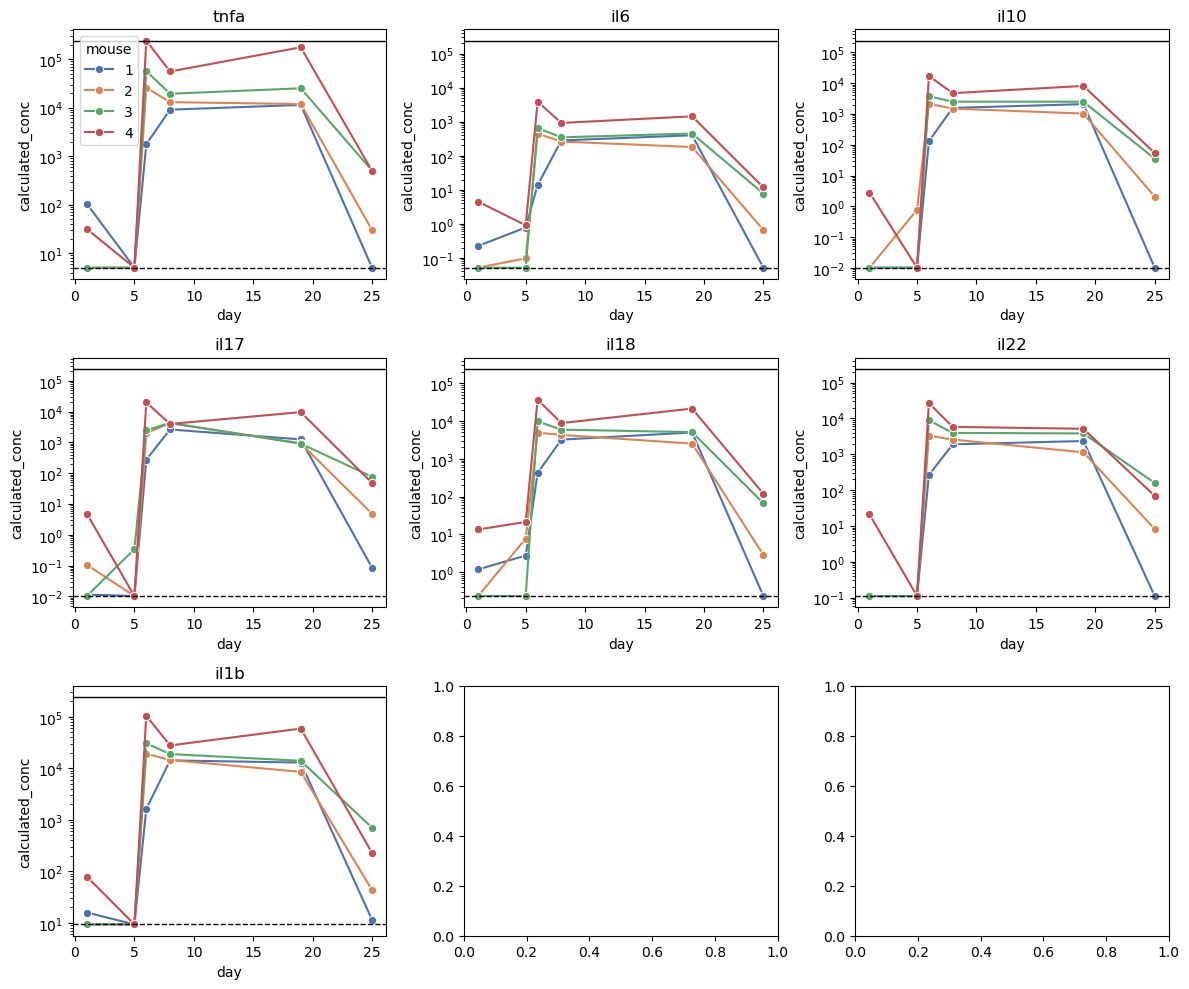

In [207]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(3, 3, figsize=(12, 10))
axes = axes.flatten()

for i, (k, df) in enumerate(vals.items()):

    #do not plot if dillution factor equals 16
    df = df[df['dilution_factor'] != 16]

    if i >= 9: break
    
    sns.lineplot(data=df, y='calculated_conc', x='day', hue='mouse', ax=axes[i], estimator=None,marker='o', palette="deep")
    #sns.scatterplot(data=df, y='calculated_conc', x='day', hue='mouse_type', ax=axes[i])
    axes[i].axhline(y=llod_conc[k]*4, color='k', linestyle='--', linewidth=1)
    axes[i].axhline(y=48*5000, color='k', linestyle='-', linewidth=1)
    axes[i].set_yscale('log')
    axes[i].set_title(k)
    if i > 0:
        axes[i].get_legend().remove()

plt.tight_layout()
plt.show()

In [208]:

statistical_results_permutation = {}

for j, (k, df) in enumerate(vals.items()):
    df = df[df['dilution_factor'] != 16]
    df_renamed = df.rename(columns={'day': 'time', 'mouse': 'mouse', 'calculated_conc': 'value'})
    W_obs, p_value = perm_test_w_label_shuffle(df_renamed, B=20000, seed=42, time_col='time', mouse_col='mouse', value_col='value', ascending=False)#perm_test_w_circular_shift(df_renamed, B=20000, seed=42, time_col='time', mouse_col='mouse', value_col='value', ascending=False)
    statistical_results_permutation[k] = {'W_observed': W_obs, 'p_value': p_value} 
statistical_results_permutation

# bh correct for multiple hypothesis testing
p_values = [statistical_results_permutation[k]['p_value'] for k in statistical_results_permutation]
adjusted_p_values = multipletests(p_values, alpha=0.05, method='fdr_bh')[1]
for i, k in enumerate(statistical_results_permutation):
    statistical_results_permutation[k]['adjusted_p_value'] = adjusted_p_values[i] 


# make results into a single dataframe
statistical_results_permutation_df = pd.DataFrame.from_dict(statistical_results_permutation, orient='index')
statistical_results_permutation_df

,W_observed,p_value,adjusted_p_value
tnfa,0.352778,0.038548,0.044973
il6,0.669444,0.001800,0.004900
il10,0.466667,0.012949,0.018129
il17,0.255556,0.195090,0.195090
il18,0.658333,0.002100,0.004900
il22,0.505556,0.000900,0.004900
il1b,0.458333,0.006350,0.011112


/var/folders/br/3tx211rj6_l8t_1qzgs1m07h0000gp/T/ipykernel_94727/1318470748.py:96: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


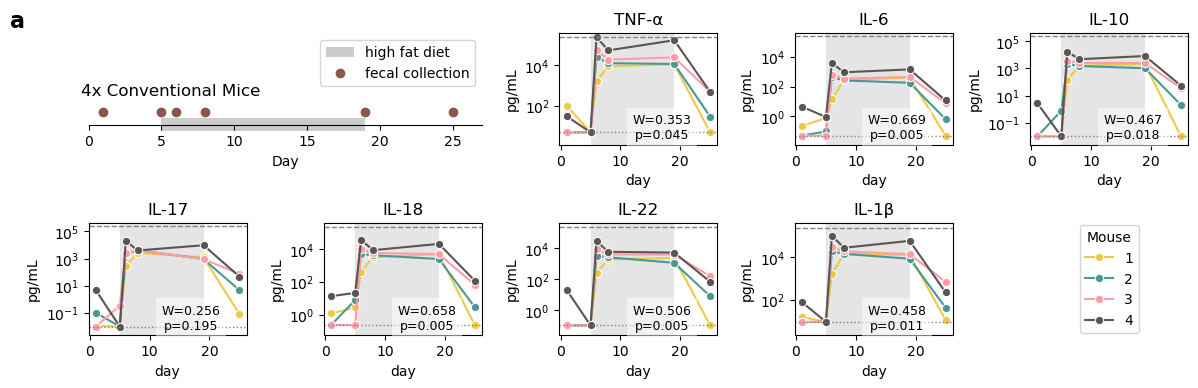

In [209]:

#import emoji

plt.rcParams['figure.facecolor'] = 'none'


mosaic = """
AABCD
EFGHI
"""
fig, ax_dict = plt.subplot_mosaic(mosaic,figsize=(12, 4), layout='constrained')

axes = list(ax_dict.values())
fig.patch.set_alpha(0.0)

ax=axes[0]

days = [1.0, 5.0,6.0, 8.0, 19,25]
pw1 = [0,5]
pw2 = [5,19] # period of high fat diet
pw3 = [19,days[-1]+3]

# Plot timeline segments with visible edges
y_pos = -0.3
height = 0.2
very_light_gray = "#f0f0f0"
light_gray = "#d3d3d3"
gray="#a9a9a9"

rect2 = Rectangle((pw2[0], y_pos), pw2[1]-pw2[0], height, facecolor="gray", alpha=0.4, edgecolor='black', linewidth=0, label='high fat diet')
ax.add_patch(rect2)

# Add text labels with visible backgrounds
ax.text(-0.5, 0.2, "4x Conventional Mice", ha='left', va='bottom', fontsize=12)
line1, = ax.plot(days, [y_pos+.3]*len(days), 'o', color='tab:brown', label='fecal collection')
ax.legend(handles=[rect2, line1], loc='upper right')


# Add feces images with visible frames
#for day in days:
#    feces_box = OffsetImage(feces, zoom=0.04)
#    ab_feces = AnnotationBbox(feces_box, (day, -0.25), frameon=False,
#                             box_alignment=(0.5, 0.5))
#    ax.add_artist(ab_feces)

# Customize plot
ax.set_ylim(-0.5, 1.2)
ax.set_xlim(-2, days[-1])
ax.set_xlabel('Day')

ax.spines['bottom'].set_position(('data', y_pos+height/2))

# Remove axis lines and ticks
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.yaxis.set_visible(False)
ax.set_xlim(0, days[-1]+2)

#define pallete for the line plots
color1="#EDC948"
color2="#499894"
color3="#FF9DA7"
color4="#5B5452"


pallete=[ color1, color2, color3, color4]

# add orange background transparent box for high fat diet period

for j, (k, df) in enumerate(vals.items()):
    df = df[df['dilution_factor'] != 16]
    i=j+1
    axes[i].add_patch(Rectangle((pw2[0], -0.5), pw2[1]-pw2[0], 1000000, facecolor="gray", alpha=0.2, edgecolor='none'))
    sns.lineplot(data=df, y='calculated_conc', x='day', hue='mouse', ax=axes[i], estimator=None,marker='o', palette=pallete)
    #axes[i].axhline(y=800, color='gray', linestyle=':', linewidth=1)
    axes[i].axhline(y=5000*48, color='gray', linestyle='--', linewidth=1)
    axes[i].axhline(y=llod_conc[k]*4, color='gray', linestyle=':', linewidth=1)
    #axes[i].axhline(y=llod_conc[k]*8/5, color='gray', linestyle='--', linewidth=1)
    axes[i].set_yscale('log')
    axes[i].set_ylabel('pg/mL')
    axes[i].set_title(display_names[k])
    axes[i].set_ylim(llod_conc[k], 400000)
    # add W and adjusted p-value to the plot
    axes[i].text(0.65, 0.15, f"W={statistical_results_permutation[k]['W_observed']:.3f}\np={statistical_results_permutation[k]['adjusted_p_value']:.3f}", horizontalalignment='center', verticalalignment='center', transform=axes[i].transAxes, fontsize=9, bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))
    if i > 0:
        axes[i].get_legend().remove()

# place legend for mice in the last unused subplot and remove axes from the subplot
handles, labels = axes[2].get_legend_handles_labels()
axes[8].legend(handles, labels, title='Mouse', loc='center')
axes[8].axis('off')

#place A in upper left corner
axes[0].text(-0.2, 1.05, "a", transform=axes[0].transAxes, fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

In [210]:
# save raw data for figures as a table remove dilution factor 16 samples and only save sample name, calculated concentration, day, and mouse
df_save=pd.DataFrame()
for k,v in vals.items():
    v = v[v['dilution_factor'] != 16]
    v_save = v[['sample', 'calculated_conc', 'day', 'mouse']].copy()
    v_save['cytokine'] = k
    df_save = pd.concat([df_save, v_save], ignore_index=True) 

df_save

,sample,calculated_conc,day,mouse,cytokine
0,1-D1/4,104.195983,1,1,tnfa
1,1-D5/4,5.038392,5,1,tnfa
2,1-D25/4,5.038392,25,1,tnfa
3,2-D1/4,5.038392,1,2,tnfa
4,1-D6/48,1758.924341,6,1,tnfa
...,...,...,...,...,...
163,3-D8/48,18986.296291,8,3,il1b
164,3-D19/48,14042.204602,19,3,il1b
165,4-D6/48,105491.373102,6,4,il1b
166,4-D8/48,27918.625712,8,4,il1b


In [211]:

with pd.ExcelWriter(statistical_data_path, mode='a', engine='openpyxl', if_sheet_exists='replace') as writer:
    statistical_results_permutation_df.to_excel(writer, sheet_name='mouse_time_series')


# save raw data for mouse figures
with pd.ExcelWriter(extended_data_path, mode='a', engine='openpyxl', if_sheet_exists='replace') as writer:  
    df_save.to_excel(writer, sheet_name='mouse_time_series_concentrations', index=False)

/opt/anaconda3/envs/cocktail/lib/python3.13/site-packages/openpyxl/workbook/child.py:99: UserWarning: Title is more than 31 characters. Some applications may not be able to read the file
  warnings.warn("Title is more than 31 characters. Some applications may not be able to read the file")


In [212]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.transforms as transforms
import re
from svgpathtools import svg2paths
from svgpath2mpl import parse_path
import matplotlib.path as mpath # Import matplotlib.path
import numpy as np # Import numpy for numerical operations

def extract_color(attr_dict):
    """
    Helper function to find the color of a path.
    SVGs store colors either in a 'fill' attribute or inside a 'style' string.
    """
    # 1. Check direct fill attribute
    if 'fill' in attr_dict and attr_dict['fill'] != 'none':
        return attr_dict['fill']

    # 2. Check inside the style attribute (e.g., style="fill:#FFFFFF;")
    if 'style' in attr_dict:
        match = re.search(r'fill:\s*([^;]+)', attr_dict['style'])
        if match and match.group(1) != 'none':
            return match.group(1)

    # Default to a dark grey if no fill is found (helpful for outlines)
    return "#333333"
"#070505"
def place_svg_on_ax(ax, svg_filepath, x_data_center, y_data_center, desired_width_in_data_units):
    """
    Places an SVG vector graphic on a Matplotlib Axes object, preserving its aspect ratio
    even if the axes' data aspect ratio is not equal.

    Args:
        ax (matplotlib.axes.Axes): The Matplotlib axes to draw on.
        svg_filepath (str): The path to the SVG file.
        x_data_center (float): The x-coordinate (in data units) for the center of the SVG.
        y_data_center (float): The y-coordinate (in data units) for the center of the SVG.
        desired_width_in_data_units (float): The desired width of the SVG in axes' data units.
    """
    paths, attributes = svg2paths(svg_filepath)

    # Calculate overall bounding box to normalize scaling
    min_x, max_x, min_y, max_y = float('inf'), float('-inf'), float('inf'), float('-inf')
    for path in paths:
        if path.bbox() is not None:
            px_min_x, px_max_x, px_min_y, px_max_y = path.bbox()
            min_x = min(min_x, px_min_x)
            max_x = max(max_x, px_max_x)
            min_y = min(min_y, px_min_y)
            max_y = max(max_y, px_max_y)

    svg_width = max_x - min_x
    svg_height = max_y - min_y

    # Calculate the base scale for x, based on desired width in data units
    base_scale_factor = desired_width_in_data_units / svg_width

    # Get the transformation matrix from data coordinates to display coordinates
    trans_data_matrix = ax.transData.get_matrix()

    # Calculate the effective scaling factors for x and y in display coordinates
    # These are the lengths of the unit vectors of the data coordinate system in display space
    scale_x_in_display = np.sqrt(trans_data_matrix[0,0]**2 + trans_data_matrix[1,0]**2)
    scale_y_in_display = np.sqrt(trans_data_matrix[0,1]**2 + trans_data_matrix[1,1]**2)

    # Calculate the compensation factor needed to maintain aspect ratio on screen
    # If scale_y_in_display is greater than scale_x_in_display, it means y-units are stretched,
    # so we need to compress our y-scaling to counteract it.
    # If scale_x_in_display is greater, y-units are compressed, so we need to expand y-scaling.
    compensation_factor = 1.0
    if scale_x_in_display != 0 and scale_y_in_display != 0:
        compensation_factor = scale_x_in_display / scale_y_in_display

    print(f"--- Debugging SVG Placement ---")
    print(f"SVG original size: ({svg_width:.2f}, {svg_height:.2f})")
    print(f"Desired width in data units: {desired_width_in_data_units:.2f}")
    print(f"Base scale factor (X): {base_scale_factor:.4f}")
    print(f"Matplotlib X scale (data to display): {scale_x_in_display:.2f} px/data_unit")
    print(f"Matplotlib Y scale (data to display): {scale_y_in_display:.2f} px/data_unit")
    print(f"Calculated Y-axis compensation factor: {compensation_factor:.4f}")

    # Calculate SVG's center in its own coordinate system
    svg_center_x = min_x + svg_width / 2
    svg_center_y = min_y + svg_height / 2

    # Calculate translation amounts to position the scaled and flipped SVG's center at (x_data_center, y_data_center)
    # Matplotlib's Y-axis is inverted relative to SVG, so adjust for that flip.
    translate_x = x_data_center - (svg_center_x * base_scale_factor)
    translate_y = y_data_center + (svg_center_y * base_scale_factor * compensation_factor) # '+' because Y is flipped

    # Create the combined affine transformation
    # Apply base_scale_factor for X, and base_scale_factor * compensation_factor for Y (with flip)
    mouse_transform = transforms.Affine2D() \
        .scale(base_scale_factor, -base_scale_factor * compensation_factor) \
        .translate(translate_x, translate_y) \
        + ax.transData

    # Loop through every piece of the mouse and add it to the plot
    for path, attr in zip(paths, attributes):
        if 'd' in attr:
            # Parse the SVG path string into an svgpath2mpl Path object
            mpl_path = parse_path(attr['d'])

            # Explicitly create a new Matplotlib Path object from the parsed path's vertices and codes
            matplotlib_path = mpath.Path(mpl_path.vertices, mpl_path.codes)

            color = extract_color(attr)

            patch = patches.PathPatch(
                matplotlib_path, # Use the newly constructed Matplotlib Path
                facecolor=color,
                edgecolor='none',
                transform=mouse_transform,
                clip_on=False
            )
            ax.add_patch(patch)


/var/folders/br/3tx211rj6_l8t_1qzgs1m07h0000gp/T/ipykernel_94727/1373492065.py:82: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


--- Debugging SVG Placement ---
SVG original size: (612.00, 397.89)
Desired width in data units: 2.75
Base scale factor (X): 0.0045
Matplotlib X scale (data to display): 19.08 px/data_unit
Matplotlib Y scale (data to display): 66.99 px/data_unit
Calculated Y-axis compensation factor: 0.2847


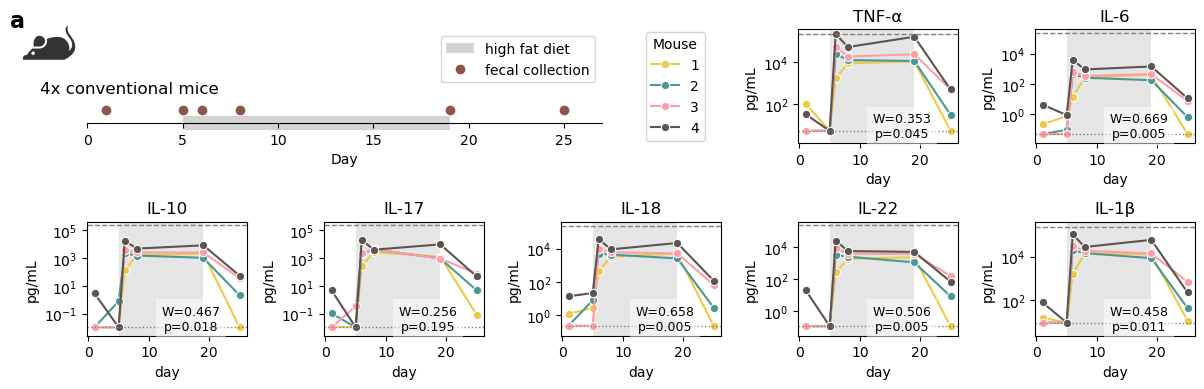

In [213]:


plt.rcParams['figure.facecolor'] = 'none'


mosaic = """
AAAAABCCDD
AAAAABCCDD
EEFFGGHHII
EEFFGGHHII
"""
fig, ax_dict = plt.subplot_mosaic(mosaic,figsize=(12, 4), layout='constrained')

axes = list(ax_dict.values())
fig.patch.set_alpha(0.0)

ax=axes[0]

days = [1.0, 5.0,6.0, 8.0, 19,25]
pw1 = [0,5]
pw2 = [5,19] # period of high fat diet
pw3 = [19,days[-1]+3]

# Plot timeline segments with visible edges
y_pos = -0.3
height = 0.2
very_light_gray = "#f0f0f0"
light_gray = "#d3d3d3"
gray="#a9a9a9"

rect2 = Rectangle((pw2[0], y_pos), pw2[1]-pw2[0], height, facecolor=gray, alpha=0.5, edgecolor='black', linewidth=0, label='high fat diet')
ax.add_patch(rect2)



# Add text labels with visible backgrounds
ax.text(-2.5, 0.2, "4x conventional mice", ha='left', va='bottom', fontsize=12)
line1, = ax.plot(days, [y_pos+.3]*len(days), 'o', color='tab:brown', label='fecal collection')
ax.legend(handles=[rect2, line1], loc='upper right')

ax.set_ylim(-0.5, 1.2)
ax.set_xlim(-2, days[-1])
ax.set_xlabel('Day')

ax.spines['bottom'].set_position(('data', y_pos+height/2))

# Remove axis lines and ticks
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.yaxis.set_visible(False)
ax.set_xlim(0, days[-1]+2)



#define pallete for the line plots
color1="#EDC948"
color2="#499894"
color3="#FF9DA7"
color4="#5B5452"

pallete=[ color1, color2, color3, color4]


for j, (k, df) in enumerate(vals.items()):
    df = df[df['dilution_factor'] != 16]
    i=j+2
    axes[i].add_patch(Rectangle((pw2[0], -0.5), pw2[1]-pw2[0], 1000000, facecolor="gray", alpha=0.2, edgecolor='none'))
    sns.lineplot(data=df, y='calculated_conc', x='day', hue='mouse', ax=axes[i], estimator=None,marker='o', palette=pallete)#deep)
    #axes[i].axhline(y=800, color='gray', linestyle=':', linewidth=1)
    axes[i].axhline(y=5000*48, color='gray', linestyle='--', linewidth=1)
    axes[i].axhline(y=llod_conc[k]*4, color='gray', linestyle=':', linewidth=1)
    #axes[i].axhline(y=llod_conc[k]*8/5, color='gray', linestyle='--', linewidth=1)
    axes[i].set_yscale('log')
    axes[i].set_ylabel('pg/mL')
    axes[i].set_title(display_names[k])
    axes[i].set_ylim(llod_conc[k], 400000)
    # add W and adjusted p-value to the plot
    axes[i].text(0.65, 0.15, f"W={statistical_results_permutation[k]['W_observed']:.3f}\np={statistical_results_permutation[k]['adjusted_p_value']:.3f}", horizontalalignment='center', verticalalignment='center', transform=axes[i].transAxes, fontsize=9, bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))
    if i > 0:
        axes[i].get_legend().remove()


plt.tight_layout()
place_svg_on_ax(axes[0], mouse_svg_path, -2, 1, 2.75) # Place mouse at (0.25, 0.55) with 0.3 plot unit width
axes[0].text(-0.15, 1.02, "a", transform=axes[0].transAxes, fontsize=16, fontweight='bold')
handles, labels = axes[2].get_legend_handles_labels()
axes[1].legend(handles, labels, title='Mouse', loc='center left', bbox_to_anchor=(-1, 0.5))
axes[1].axis('off')

plt.savefig(figures+'mouse_series_main.pdf', bbox_inches='tight')
plt.show()